In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Ari\Desktop\DATA SET\retail-sales-analysis\1. data\cleaning_retail.csv')
df.head()

,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Year,Month,Day,Shipping_Days,Sales_Capped
0,2017-11-08,2017-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420.0,South,Furniture,Bookcases,261.9600,2017,11,8,3,261.960
1,2017-11-08,2017-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420.0,South,Furniture,Chairs,731.9400,2017,11,8,3,500.108
2,2017-06-12,2017-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036.0,West,Office Supplies,Labels,14.6200,2017,6,12,4,14.620
3,2016-10-11,2016-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Furniture,Tables,957.5775,2016,10,11,7,500.108
4,2016-10-11,2016-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Office Supplies,Storage,22.3680,2016,10,11,7,22.368


# 3.1. BASIC DESCRIPTIVE ANALYSIS

### SALES BY YEAR

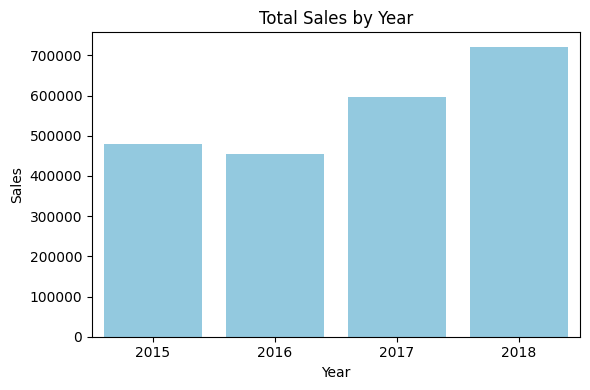

In [4]:
sales_year = df.groupby("Year")["Sales"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=sales_year, x="Year", y="Sales",color='skyblue')
plt.title("Total Sales by Year")
plt.tight_layout()
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\yearly_sales_trend.png', bbox_inches="tight")
plt.show()


### SALES BY MONTH

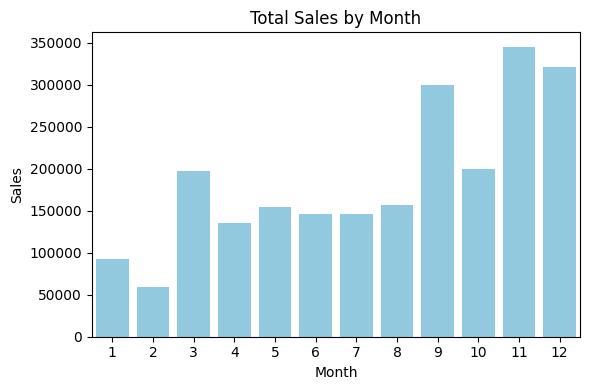

In [5]:
sales_year = df.groupby("Month")["Sales"].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=sales_year, x="Month", y="Sales",color='skyblue')
plt.title("Total Sales by Month")
plt.tight_layout()
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\monthly_seasonality.png', bbox_inches="tight")
plt.show()

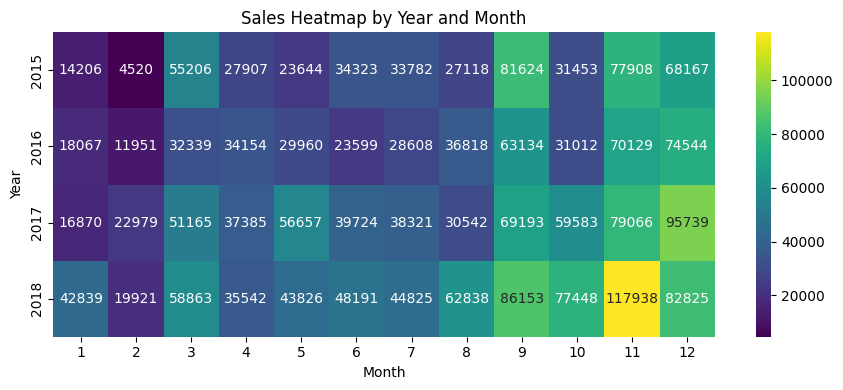

In [20]:
pivot = df.pivot_table(values="Sales", index="Year", columns="Month", aggfunc="sum")
plt.figure(figsize=(9,4))
sns.heatmap(pivot, annot=True, fmt=".00f", cmap="viridis")
plt.title("Sales Heatmap by Year and Month")
plt.tight_layout()
plt.show()


# 3.2. SALES BY CATEGORY AND SUB-CATEGORY

### TOTAL SALES BY CATEGORY

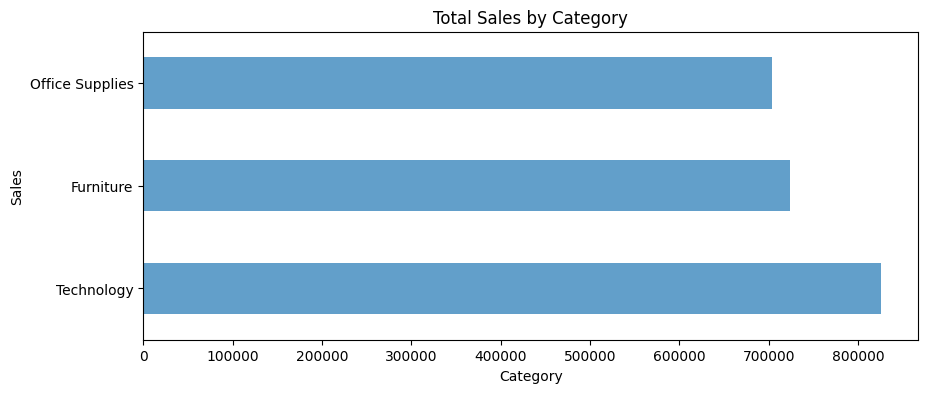

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

In [6]:
# Total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,4))
category_sales.plot(kind='barh', alpha=0.7)
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xlabel('Category')
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\sales_by_category.png', bbox_inches="tight")
plt.show()

category_sales

### TOTAL SALES BY SUB-CATEGORY

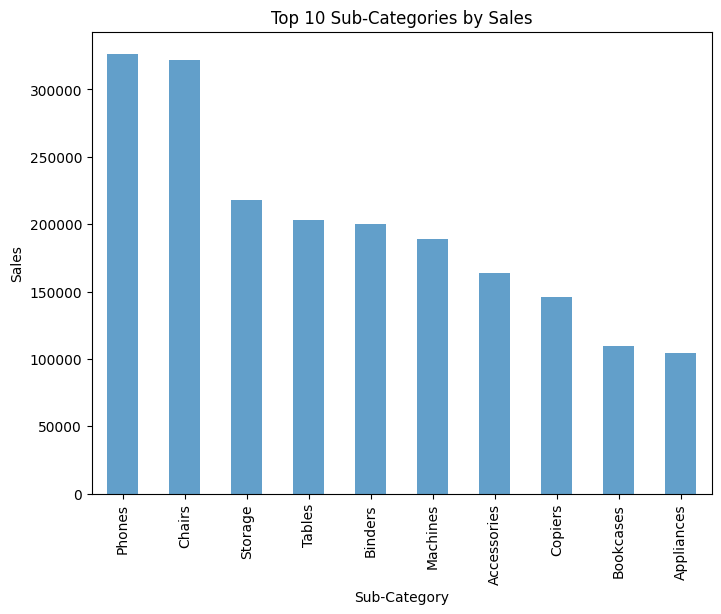

Sub-Category
Phones         326487.6980
Chairs         322107.5310
Storage        217779.1020
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    163881.6900
Copiers        146248.0940
Bookcases      109408.2987
Appliances     104075.4630
Name: Sales, dtype: float64

In [29]:
# Total sales by sub-category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
subcat_sales.head(10).plot(kind='bar', alpha=0.7)
plt.title('Top 10 Sub-Categories by Sales')
plt.ylabel('Sales')
plt.xlabel('Sub-Category')
plt.show()
subcat_sales.head(10)


### CATEGORY VS YEAR HEAT MAP

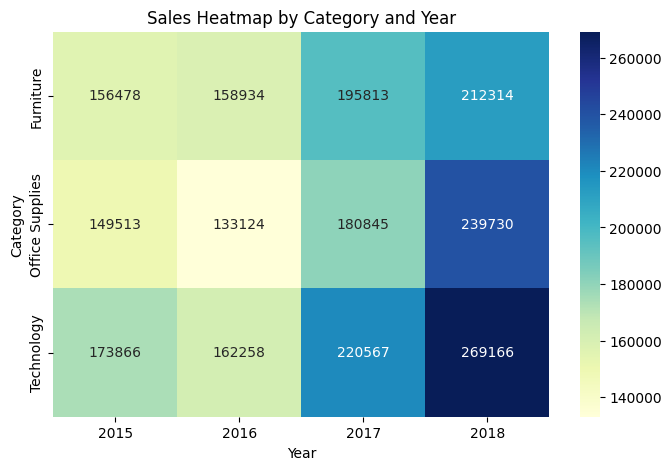

Year,2015,2016,2017,2018
Category,,,,
Furniture,156477.8811,158933.7674,195813.040,212313.7872
Office Supplies,149512.8200,133124.4070,180845.236,239730.3610
Technology,173865.5070,162257.7310,220567.214,269165.6610


In [27]:
heat_cat = df.pivot_table(values='Sales', index='Category', columns='Year', aggfunc='sum')
plt.figure(figsize=(8,5))
sns.heatmap(heat_cat, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Sales Heatmap by Category and Year')
plt.show()
heat_cat

# 3.3. SALES BY CUSTOMER SEGMENT

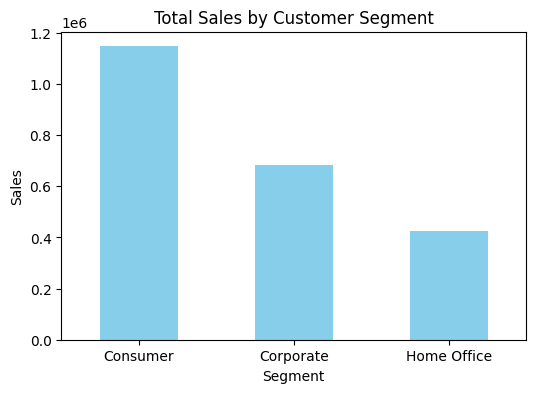

Segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: Sales, dtype: float64

In [7]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
segment_sales.plot(kind='bar', color='skyblue')
plt.title("Total Sales by Customer Segment")
plt.ylabel("Sales")
plt.xlabel("Segment")
plt.xticks(rotation=0)
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\sales_by_segment.png', bbox_inches="tight")
plt.show()

segment_sales

# 3.4. SALES BY REGION AND CITY

### SALES BY REGION

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


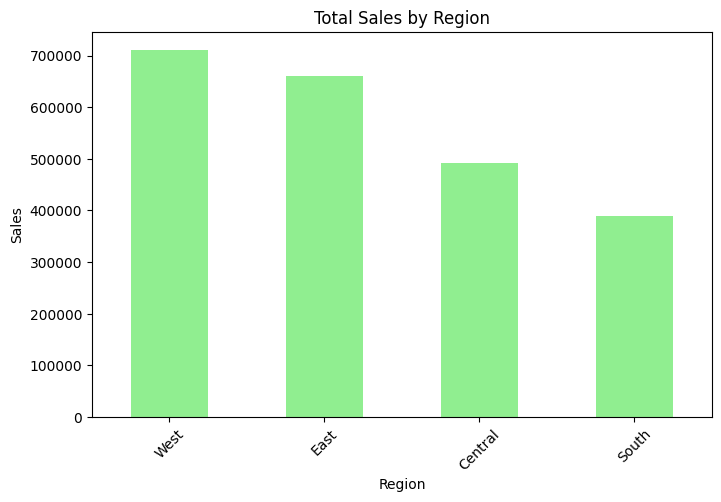

In [37]:
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(sales_region)

plt.figure(figsize=(8,5))
sales_region.plot(kind='bar', color='lightgreen')
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.show()


### CITIES WITH THE HIGHEST SALES

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


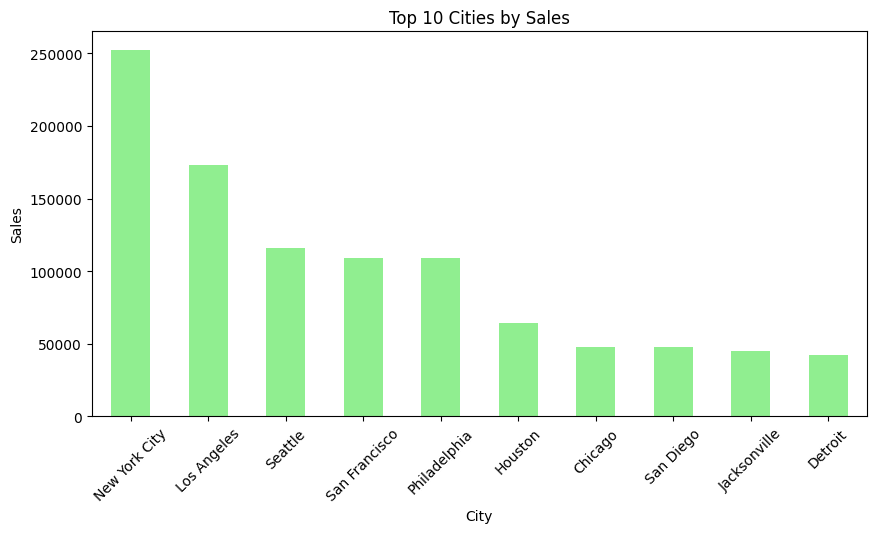

In [38]:
sales_city = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
print(sales_city)

plt.figure(figsize=(10,5))
sales_city.plot(kind='bar', color='lightgreen')
plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()


### HEAT MAP BY REGION AND CATEGORY

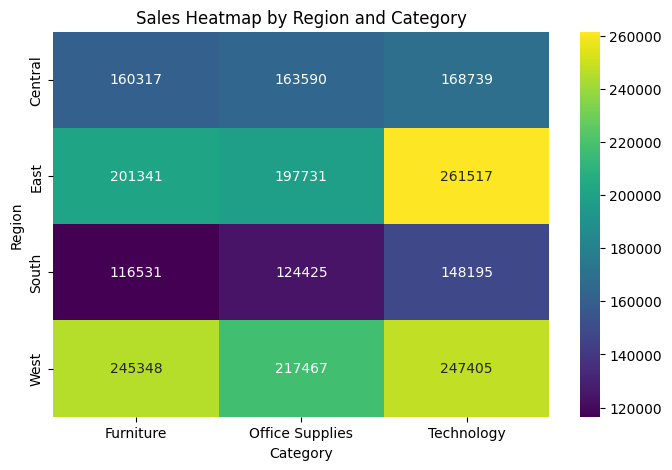

In [39]:
region_category = df.pivot_table(values="Sales", index="Region", columns="Category", aggfunc="sum")

plt.figure(figsize=(8,5))
sns.heatmap(region_category, annot=True, fmt=".0f", cmap="viridis")
plt.title("Sales Heatmap by Region and Category")
plt.show()


# 3.5 MONTHLY PATTERNS, SEASONALITY AND TRENDS

- **SALES TREND BY MONTH**
- **SEASONALITY (PEAKS, DROPS)**
- **STRONGEST YEARS**
- **KEY MONTHS FOR PROMOTIONS**

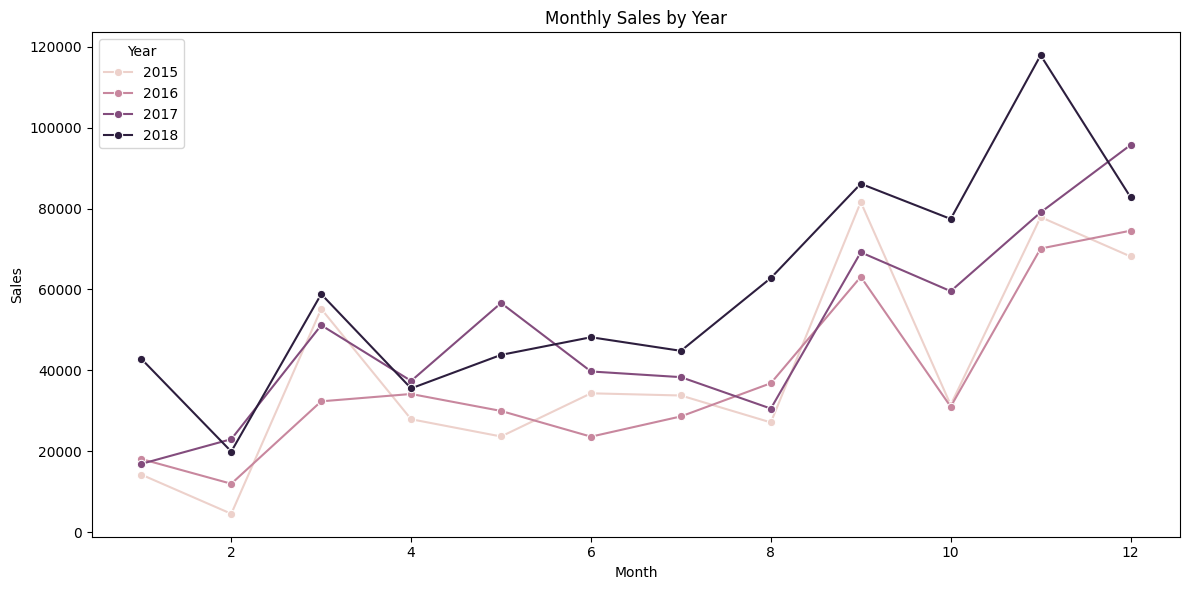

In [2]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", hue="Year", marker="o")
plt.title("Monthly Sales by Year")
plt.tight_layout()
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\month_sales_by_years.png', bbox_inches="tight")
plt.show()


### Year on year sales comparison 

In [3]:
yearly_sales = df.groupby('Year')['Sales'].sum().round(2)
yearly_growth = yearly_sales.pct_change().round(3) * 100

print("Sales by year:")
print(yearly_sales)

print("\nGrowth (%):")
print(yearly_growth)


Sales by year:
Year
2015    479856.21
2016    454315.91
2017    597225.49
2018    721209.81
Name: Sales, dtype: float64

Growth (%):
Year
2015     NaN
2016    -5.3
2017    31.5
2018    20.8
Name: Sales, dtype: float64


# 3.6 SALES OUTLIERS

### 🔵 Boxplot method

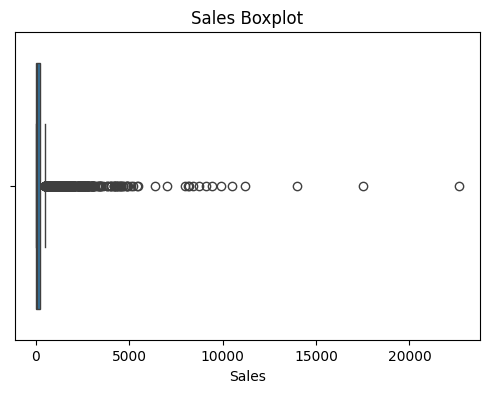

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Boxplot")
plt.savefig(r'C:\Users\Ari\Desktop\DATA SET\Retail Sales Analysis\3. figures\box_plot_outliers.png', bbox_inches="tight")
plt.show()

### 🔵Interquartile Range method (IQR)

In [55]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print("Number of outliers per IQR:", len(outliers_iqr))

Cantidad de outliers por IQR: 1141


### 🔵 Z-SCORE method

In [5]:
from scipy import stats
import numpy as np

df['z_score'] = np.abs(stats.zscore(df['Sales']))
outliers_z = df[df['z_score'] > 3]
print("Number of outliers per Z-score:", len(outliers_z))

Number of outliers per Z-score: 122


# 3.7. Outliers by category and region

### 🔵 Interquartile Range method (IQR) 

In [58]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Outlier_IQR"] = (df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)

outliers_por_categoria = df[df["Outlier_IQR"] == True].groupby("Category").size()
outliers_por_region = df[df["Outlier_IQR"] == True].groupby("Region").size()

print(outliers_por_categoria)

Category
Furniture          458
Office Supplies    290
Technology         393
dtype: int64


In [59]:
outliers_por_region = df[df["Outlier_IQR"] == True].groupby("Region").size()
print(outliers_por_region)

Region
Central    253
East       322
South      198
West       368
dtype: int64


### 🔵 Z-SCORE method

In [69]:
from scipy import stats
import numpy as np

# 1. Calcular Z-score
df['z_score'] = np.abs(stats.zscore(df['Sales']))

# 2. Crear la columna booleana de outliers
df['Outlier_Z'] = df['z_score'] > 3

# 3. Filtrar outliers
outliers_z = df[df['Outlier_Z']]

# 4. Outliers por categoría
outliers_z_categoria = outliers_z.groupby("Category").size()

# 5. Mostrar
print(outliers_z_categoria)


Category
Furniture          31
Office Supplies    29
Technology         62
dtype: int64


In [70]:
outliers_z_region = df[df["Outlier_Z"] == True].groupby("Region").size()
print(outliers_z_region)

Region
Central    23
East       41
South      23
West       35
dtype: int64
